In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent
print("PROJECT ROOT ==>", PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT))

from src.landmark_eval import evaluate_all_scans, evaluate_dataset, load_gt, load_pred
from src.pred_gt_viewer_viz import visualize_pred_and_gt

from src.mesh_fun import (
    load_mesh, load_landmarks, create_landmark_spheres, visualize
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import open3d as o3d


PROJECT ROOT ==> c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
LANDMARK_PALETTE = {
    "Mesial":        [1.0, 0.0, 0.0],   # rosso
    "Distal":        [0.0, 1.0, 0.0],   # verde
    "Cusp":          [0.0, 0.0, 1.0],   # blu
    "InnerPoint":    [1.0, 1.0, 0.0],   # giallo
    "OuterPoint":    [0.0, 1.0, 1.0],   # ciano
    "FacialPoint":    [1.0, 0.0, 1.0],   # magenta
}

FDI_palette = {
    #Quadrante 1 (blu)
    11:[31,119,180], 12:[40,140,200], 13:[55,160,220], 14:[70,180,240],
    15:[90,200,255], 16:[110,210,255], 17:[130,220,255], 18:[150,230,255],

    #Quadrante 2 (verde)
    21:[44,160,44], 22:[60,180,60], 23:[80,200,80], 24:[100,220,100],
    25:[120,240,120], 26:[140,255,140], 27:[160,255,160], 28:[180,255,180],

    #Quadrante 3 (arancione)
    31:[255,127,14], 32:[255,150,40], 33:[255,170,60], 34:[255,190,80],
    35:[255,210,100], 36:[255,230,120], 37:[255,240,140], 38:[255,250,160],

    #Quadrante 4 (viola)
    41:[148,103,189], 42:[168,120,200], 43:[188,140,210], 44:[208,160,220],
    45:[228,180,230], 46:[248,200,240], 47:[255,210,250], 48:[255,230,255],

    #Gingiva
    0:[100,100,100]
}

In [4]:
DATA_ROOT = PROJECT_ROOT / "dataset"
SCANS = DATA_ROOT / "toothinstancenet_input"
GT_ROOT = SCANS
PRED_CSV = DATA_ROOT / "model_predictions" / "ynlab" / "predictions.csv"

print("SCANS:", SCANS)
print("GT_ROOT:", GT_ROOT)
print("PRED_CSV:", PRED_CSV)


SCANS: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\toothinstancenet_input
GT_ROOT: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\toothinstancenet_input
PRED_CSV: c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans\dataset\model_predictions\ynlab\predictions.csv


In [ ]:
###check obj
objs = sorted(list(SCANS.glob("*.obj")))
print("Numero totale di OBJ:", len(objs))


In [14]:
results_global, mAP_global, mAR_global = evaluate_dataset(GT_ROOT, PRED_CSV, categories=list(LANDMARK_PALETTE.keys()))

print("=== RISULTATI GLOBALI (ufficiali) ===")
for cat, vals in results_global.items():
    print(f"{cat}: AP={vals['AP']:.4f}, AR={vals['AR']:.4f}")

print("\nMETRICHE TOTALI:")
print(f"mAP = {mAP_global:.4f}")
print(f"mAR = {mAR_global:.4f}")


=== RISULTATI GLOBALI (ufficiali) ===
Mesial: AP=0.6017, AR=0.4783
Distal: AP=0.5437, AR=0.4456
Cusp: AP=0.6098, AR=0.4455
InnerPoint: AP=0.5919, AR=0.4564
OuterPoint: AP=0.6140, AR=0.4829
FacialPoint: AP=0.5922, AR=0.5423

METRICHE TOTALI:
mAP = 0.5922
mAR = 0.4752


In [ ]:
=== RISULTATI GLOBALI (ufficiali) ===
Mesial: AP=0.6017, AR=0.5236
Distal: AP=0.5437, AR=0.4854
Cusp: AP=0.6098, AR=0.5539
InnerPoint: AP=0.5919, AR=0.5183
OuterPoint: AP=0.6140, AR=0.5192
FacialPoint: AP=0.5922, AR=0.4849

METRICHE TOTALI:
mAP = 0.5922
mAR = 0.5142

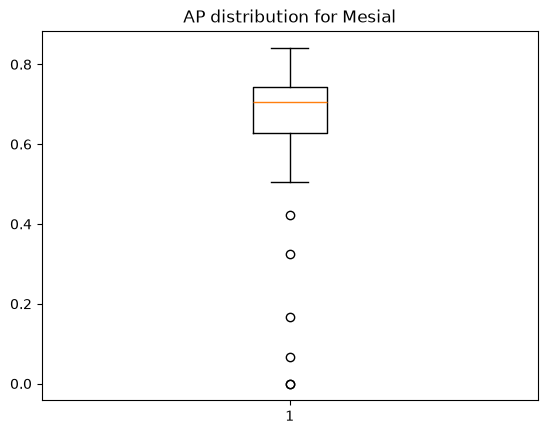

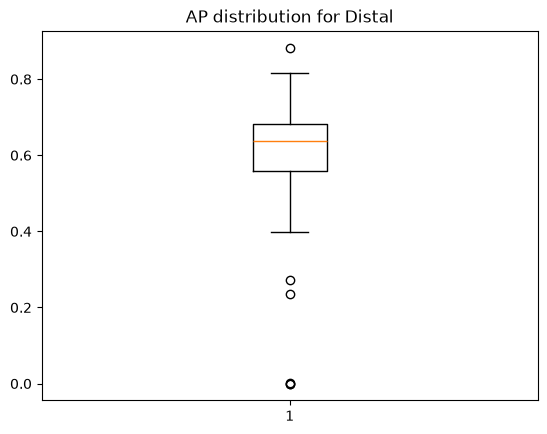

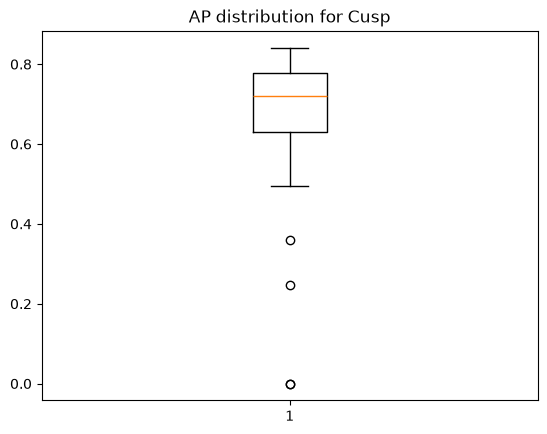

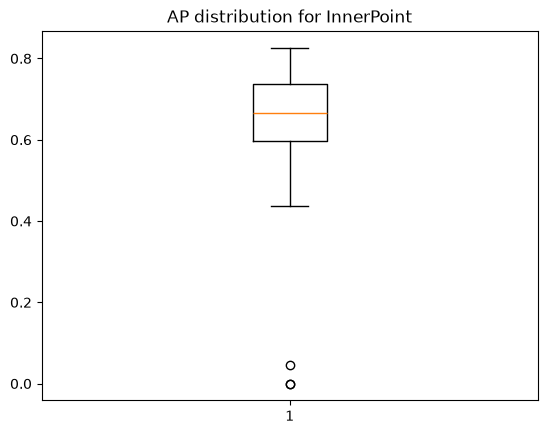

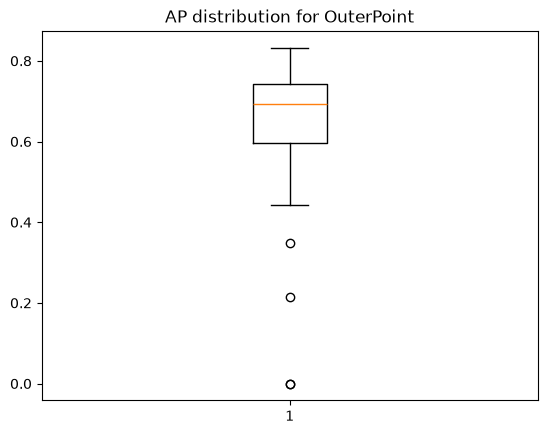

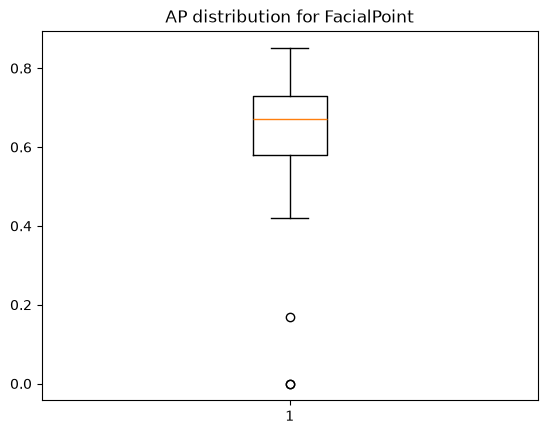

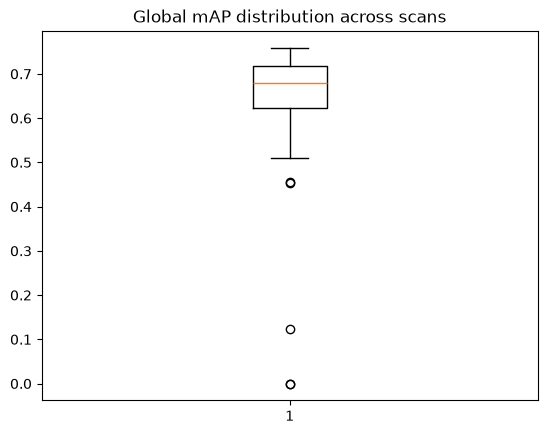

In [6]:
results = evaluate_all_scans(GT_ROOT, PRED_CSV, list(LANDMARK_PALETTE.keys()))

# Boxplot per categoria (AP)
import matplotlib.pyplot as plt

for cat in list(LANDMARK_PALETTE.keys()):
    plt.figure()
    plt.boxplot(results["ap_per_scan"][cat])
    plt.title(f"AP distribution for {cat}")
    plt.show()

# Boxplot globale (mAP)
plt.figure()
plt.boxplot(results["mAP_per_scan"])
plt.title("Global mAP distribution across scans")
plt.show()


In [15]:
def compute_quantile_table(values, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    values = np.array(values)
    qvals = np.quantile(values, quantiles)
    return pd.DataFrame({
        "quantile": quantiles,
        "value": qvals
    })

In [16]:
quantile_tables_ap = {}
quantile_tables_ar = {}

for cat in list(LANDMARK_PALETTE.keys()):
    vals_ap = results["ap_per_scan"][cat]
    vals_ar = results["ar_per_scan"][cat]

    if len(vals_ap) > 0:
        quantile_tables_ap[cat] = compute_quantile_table(vals_ap)
    if len(vals_ar) > 0:
        quantile_tables_ar[cat] = compute_quantile_table(vals_ar)


In [17]:
quantile_mAP = compute_quantile_table(results["mAP_per_scan"])
quantile_mAR = compute_quantile_table(results["mAR_per_scan"])

print("\n=== Quantile table – Global mAP per scan ===")
print(quantile_mAP)

print("\n=== Quantile table – Global mAR per scan ===")
print(quantile_mAR)



=== Quantile table – Global mAP per scan ===
   quantile     value
0      0.10  0.550665
1      0.25  0.623364
2      0.50  0.679340
3      0.75  0.718218
4      0.90  0.744729

=== Quantile table – Global mAR per scan ===
   quantile     value
0      0.10  0.443229
1      0.25  0.496631
2      0.50  0.542408
3      0.75  0.569211
4      0.90  0.603092


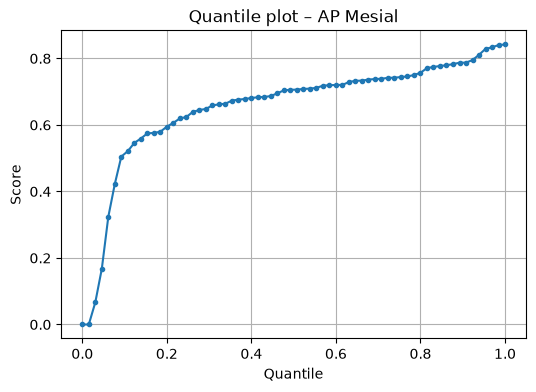

In [8]:
def plot_quantile(values, title):
    # Ordina i valori
    sorted_vals = np.sort(values)

    # Normalizza l’asse X in [0,1]
    quantiles = np.linspace(0, 1, len(sorted_vals))

    plt.figure(figsize=(6,4))
    plt.plot(quantiles, sorted_vals, marker='o', markersize=3)
    plt.title(title)
    plt.xlabel("Quantile")
    plt.ylabel("Score")
    plt.grid(True)
    plt.show()

# Esempio: quantile plot per categoria Mesial
plot_quantile(results["ap_per_scan"]["Mesial"], "Quantile plot – AP Mesial")

In [ ]:
import pandas as pd
df = pd.read_csv(PRED_CSV, header=None, names=[
    "scan", "coord_x", "coord_y", "coord_z", "class", "score"
])
print(df.columns)

In [ ]:
#parte statistica descrittiva box plot
objs = sorted(list(SCANS.glob("*.obj")))
all_results = []

for obj in objs:
    scan_name = obj.stem
    gt_json = GT_ROOT / f"{scan_name}_kpt.json"

    if not gt_json.exists():
        print("GT mancante:", scan_name)
        continue

    results, mAP, mAR = evaluate_scan(gt_json, PRED_CSV, scan_name)

    all_results.append({
        "scan": scan_name,
        "mAP": mAP,
        "mAR": mAR,
        **{f"AP_{cat}": results[cat]["AP"] for cat in results},
        **{f"AR_{cat}": results[cat]["AR"] for cat in results},
    })

df = pd.DataFrame(all_results)
df.head()
plt.figure(figsize=(12,6))
sns.boxplot(data=df[["AP_cusp", "AP_facial", "AP_inner_outer", "AP_mesial_distal"]])
plt.title("Distribuzione AP per categoria (per scan)")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df[["AR_cusp", "AR_facial", "AR_inner_outer", "AR_mesial_distal"]])
plt.title("Distribuzione AR per categoria (per scan)")
plt.show()


In [ ]:
df_summary = df[["mAP", "mAR"]].describe()
df_summary


In [ ]:
# 7. Visualizzazione interattiva (mesh + landmark GT)
case = "AKBDPB4C"
arc = "upper"
scan_name = f"{case}_{arc}"

mesh_path = SCANS / f"{scan_name}.obj"
gt_json = GT_ROOT / f"{scan_name}__kpt.json"

coords_gt, classes_gt = load_landmarks(gt_json)
mesh = load_mesh(mesh_path)
spheres_gt = create_landmark_spheres(coords_gt, classes_gt, LANDMARK_PALETTE)

visualize(mesh, spheres_gt, view="front")


In [ ]:
#Visualizzazione predizioni + GT + screenshot (come Figure 11 del paper)
print('scan_name', scan_name)
out_dir = PROJECT_ROOT / "screenshots_test" / scan_name
visualize_pred_and_gt(mesh_path, PRED_CSV, gt_json, scan_name, out_dir, LANDMARK_PALETTE)

print("Screenshot salvati in:", out_dir)


In [ ]:
# Visualizzazione predizioni (solo predetti)
from src.pred_gt_viewer_viz import load_pred_landmarks

coords_pred, classes_pred = load_pred_landmarks(PRED_CSV, scan_name)
mesh = load_mesh(mesh_path)
spheres_pred = create_landmark_spheres(coords_pred, classes_pred, LANDMARK_PALETTE)

visualize(mesh, spheres_pred, view="front")


In [ ]:
#Visualizzazione GT + predizioni insieme (per debugging)
mesh = load_mesh(mesh_path)

spheres_gt = create_landmark_spheres(coords_gt, classes_gt, LANDMARK_PALETTE)
spheres_pred = create_landmark_spheres(coords_pred, classes_pred, LANDMARK_PALETTE)

visualize(mesh, spheres_gt + spheres_pred, view="front")
